### PanACEA Btz-043 MBLA analysis
#### Biomarker PCA

- Developed by: Mairi McClean
- Affiliation: Institute of Computational Biology, Helmholtz Munich; Infection and Immunity Group, LMU Klinikum
- v240827


### import modules

In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
from matplotlib import pyplot as plt
from statsmodels.tsa.stattools import adfuller

import matplotlib.cm as cm
from scipy import stats
from scipy import linalg
from tqdm import tqdm
import time
from ppca import PPCA

np.random.seed(30)

## PCA
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

#### Read data

In [2]:
## from 'biomarker_formatting.Rmd"; same data used for dose-response model; no outliers removed
X1=pd.read_csv('/Users/mairi.mcclean/Desktop/btz/processed/new_cleaned_data/250612mm_stg1_biomarkerdf.csv', index_col=0)
X2=pd.read_csv('/Users/mairi.mcclean/Desktop/btz/processed/new_cleaned_data/250612mm_stg2_biomarkerdf.csv', index_col=0)

- Format dfs to fill missing tx arm labels

In [3]:
X1['Assigned.Arm'] = X1.groupby('Subject.ID')['Assigned.Arm'].transform(lambda x: x.ffill().bfill())
X2['Assigned.Arm'] = X2.groupby('Subject.ID')['Assigned.Arm'].transform(lambda x: x.ffill().bfill())

In [4]:
df_full = pd.concat([X1, X2])

In [5]:
# dose-respose
# pkpd - st1 and 2 together, no RIF

- Dose-response PCA object

> Run PCA on Stage 2 only patients for the dose-response model

- PK-PD model

> Run PCA on all stage 1 and stage 2 patients together; or run by stage and then concatenate?
> Without RIF patients

In [5]:
X2_noRIF=X2.drop(X2[X2['Assigned.Arm']== 'Arm 4: Rifafour'].index)
pkpd = pd.concat([X1, X2_noRIF])

# Calculate CV (Coefficient of variation)

In [7]:
df_full

,Subject.ID,Day,logCFU,logTTP,logMBLA,Assigned.Arm,stage
1,11001,0,4.113943,2.353147,4.709433,Cohort 1: BTZ 250mg,Stage 1
2,11001,2,4.249198,2.371068,4.472511,Cohort 1: BTZ 250mg,Stage 1
3,11001,3,3.354108,2.433770,3.729635,Cohort 1: BTZ 250mg,Stage 1
4,11001,4,4.685742,2.282169,4.964370,Cohort 1: BTZ 250mg,Stage 1
5,11001,6,4.041393,2.389166,3.644293,Cohort 1: BTZ 250mg,Stage 1
...,...,...,...,...,...,...,...
388,22085,11,4.301030,2.364551,5.160744,Arm 1: BTZ 1000mg,Stage 2
389,22087,0,6.283513,2.059830,6.601439,Arm 3: BTZ 250mg,Stage 2
390,22087,2,5.919078,2.089905,6.613831,Arm 3: BTZ 250mg,Stage 2
391,22087,3,5.164353,2.033424,6.463258,Arm 3: BTZ 250mg,Stage 2


In [55]:
pkpd

,Subject.ID,Day,logCFU,logTTP,logMBLA,Assigned.Arm,stage
1,11001,0,4.113943,2.353147,4.709433,Cohort 1: BTZ 250mg,Stage 1
2,11001,2,4.249198,2.371068,4.472511,Cohort 1: BTZ 250mg,Stage 1
3,11001,3,3.354108,2.433770,3.729635,Cohort 1: BTZ 250mg,Stage 1
4,11001,4,4.685742,2.282169,4.964370,Cohort 1: BTZ 250mg,Stage 1
5,11001,6,4.041393,2.389166,3.644293,Cohort 1: BTZ 250mg,Stage 1
...,...,...,...,...,...,...,...
388,22085,11,4.301030,2.364551,5.160744,Arm 1: BTZ 1000mg,Stage 2
389,22087,0,6.283513,2.059830,6.601439,Arm 3: BTZ 250mg,Stage 2
390,22087,2,5.919078,2.089905,6.613831,Arm 3: BTZ 250mg,Stage 2
391,22087,3,5.164353,2.033424,6.463258,Arm 3: BTZ 250mg,Stage 2


In [8]:
assays = df_full.columns.difference(['Subject.ID', 'Day', 'Assigned.Arm','stage'])

# Step 1: Calculate the overall CV for each assay
overall_cv = df_full[assays].std() / df_full[assays].mean() * 100

# Step 2: Calculate the CV for each assay at each timepoint
cv_by_timepoint = df_full.groupby('Day').apply(lambda group: group[assays].std() / group[assays].mean() * 100)

# Results for Step 2 in a table format (rows: timepoints, columns: assays)
cv_by_timepoint_table = cv_by_timepoint.reset_index()

print("Overall CV for each assay:")
print(overall_cv)
print("\nCV for each assay at each timepoint:")
print(cv_by_timepoint_table)

Overall CV for each assay:
logCFU     20.018715
logMBLA    16.798442
logTTP      6.883788
dtype: float64

CV for each assay at each timepoint:
   Day     logCFU    logMBLA    logTTP
0    0  16.633799  11.003123  5.734171
1    2  16.899804  13.932334  7.066707
2    3  17.777920  13.390840  5.745500
3    4  15.551982  13.652625  5.576455
4    6  15.961695  13.831572  6.168647
5    8  19.695120  16.688612  5.684441
6   11  20.833023  22.541659  6.364313
7   14  22.800834  19.011133  5.568087


/var/folders/g6/vfgrx_y95ml0h2lsgfx4jg6jwvdsz3/T/ipykernel_38863/4094433038.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cv_by_timepoint = df_full.groupby('Day').apply(lambda group: group[assays].std() / group[assays].mean() * 100)


# PCA

#### Pre model checks

> Check if data is stationary

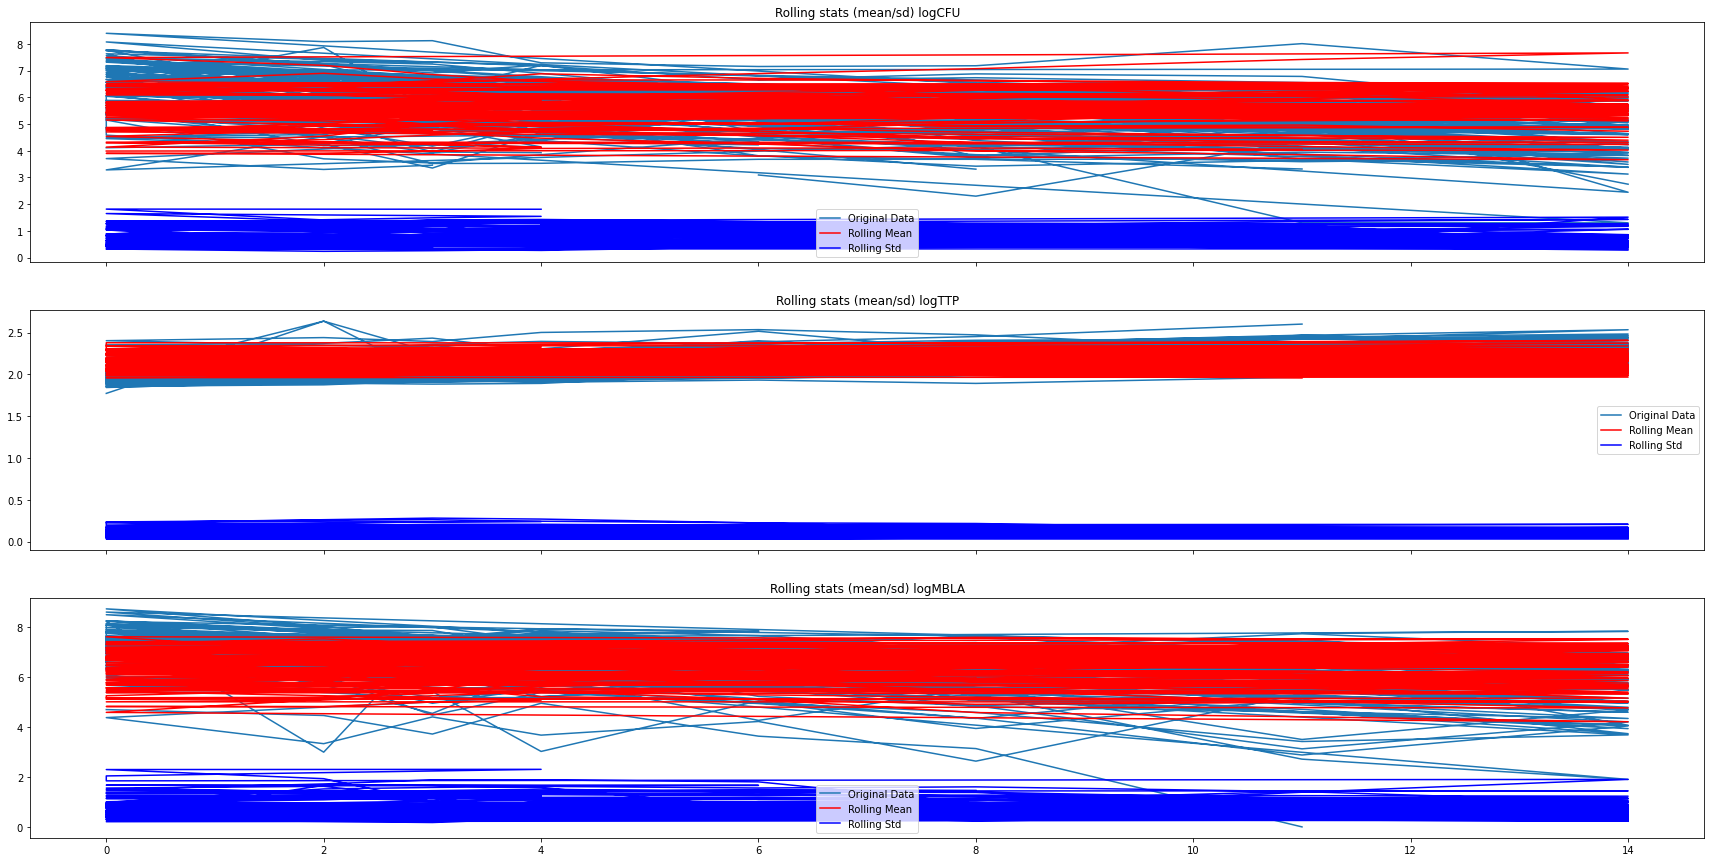

In [38]:
# Get a rolling mean per person
rolling_mean0 = df_full['logCFU'].rolling(window=8).mean() 
rolling_std0 = df_full['logCFU'].rolling(window=8).std()

rolling_mean1 = df_full['logTTP'].rolling(window=8).mean() 
rolling_std1 = df_full['logTTP'].rolling(window=8).std()

rolling_mean2 = df_full['logMBLA'].rolling(window=8).mean() 
rolling_std2 = df_full['logMBLA'].rolling(window=8).std()
fig, (ax1, ax2, ax3) = plt.subplots(3, sharex=True)
ax1.plot(df_full['Day'], df_full['logCFU'], label='Original Data')
ax1.plot(df_full['Day'],rolling_mean0, color='red', label='Rolling Mean')
ax1.plot(df_full['Day'],rolling_std0, color='blue', label='Rolling Std')
ax1.set_title('Rolling stats (mean/sd) logCFU')
ax1.legend()


ax2.plot(df_full['Day'], df_full['logTTP'], label='Original Data')
ax2.plot(df_full['Day'],rolling_mean1, color='red', label='Rolling Mean')
ax2.plot(df_full['Day'],rolling_std1, color='blue', label='Rolling Std')
ax2.set_title('Rolling stats (mean/sd) logTTP')
ax2.legend()

ax3.plot(df_full['Day'], df_full['logMBLA'], label='Original Data')
ax3.plot(df_full['Day'],rolling_mean2, color='red', label='Rolling Mean')
ax3.plot(df_full['Day'],rolling_std2, color='blue', label='Rolling Std')
ax3.set_title('Rolling stats (mean/sd) logMBLA')
ax3.legend()

plt.show()


In [42]:
check = df_full['logMBLA'].dropna() # change per assay
# Run the ADF test
adfuller(check)
## data is stationary - no need to do first difference

(-4.4554873601028735,
 0.0002364486149447148,
 17,
 535,
 {'1%': -3.4426321555520905,
  '5%': -2.86695748394138,
  '10%': -2.5696553279762426},
 1316.3619133595485)

### Dose-response

In [18]:
X_pca=X2.copy()

In [19]:
pp_df = df_full.drop(columns=['Assigned.Arm', 'stage'])
cols = ['logTTP','logCFU','logMBLA'] #'Day_scale',
subset_df = pp_df[cols]
cs_df = (subset_df - subset_df.mean(0)) / subset_df.std(0) # centre/scale without df grouping
pp_df[cols] = cs_df
pp_df = pp_df.set_index(['Subject.ID','Day'])

In [20]:
pp_df.dropna(axis=0, subset=['logCFU', 'logTTP', 'logMBLA'], how='all', inplace=True) # drop instances of no values
pp_df

logCFU    logTTP   logMBLA
Subject.ID Day                              
11001      0   -1.239214  1.436467 -1.596445
           2   -1.115724  1.558042 -1.815612
           3   -1.932958  1.983402 -2.502813
           4   -0.717151  0.954966 -1.360614
           6   -1.305454  1.680817 -2.581759
...                  ...       ...       ...
22085      11  -1.068400  1.513833 -1.178957
22087      0    0.741646 -0.553344  0.153765
           2    0.408910 -0.349319  0.165229
           3   -0.280170 -0.732479  0.025941
           4   -0.076532  0.032088 -0.172836

[562 rows x 3 columns]

#### Different combinations

In [21]:
## CFU + MGIT
CM_ppca = pp_df.drop(columns='logMBLA')

## MBLA + MGIT
MM_ppca = pp_df.drop(columns='logCFU')

## CFU+MGIT
CMbla_ppca = pp_df.drop(columns='logTTP')

In [22]:
ppca = PPCA()
ppca.fit(pp_df.values, d=2) #(verbose=True) == convergence output # d== n components

In [23]:
variance_explained = ppca.var_exp
components = ppca.data # imputed values
model_params = ppca.C # loadings?
component_mat = ppca.transform() # get components

pp_df['pc1'] = component_mat[:,0] # add PC1 to og df
pp_df['pc2'] = component_mat[:,1] # add PC2 to og df
print(variance_explained)

[0.88405849 0.9445205 ]


In [24]:
model_params # LOADINGS (features x pcs)

array([[-0.5795154 ,  0.24326346],
       [ 0.5776265 , -0.55066462],
       [-0.57489958, -0.79849319]])

In [62]:
ppca.save('mypcamodel251110_ALL_patients_CTM')#shoulda, woulda, coulda

In [ ]:
#ppca.load('mypcamodel080825.npy')

In [14]:
pp_df=pp_df.reset_index()

In [15]:
pp_df_full = pd.merge(pp_df, df_full[['Subject.ID','Day', 'Assigned.Arm']], on=['Subject.ID','Day'], how='left')

#### Plots

In [ ]:
plt.rcParams['figure.figsize'] = [8, 6]
test = CMbla_ppca_df_full[["Subject.ID", "Day", "pc1", 'pc2', "Assigned.Arm"]]
df_plot = pd.pivot(test, index="Day", columns="Subject.ID", values="pc1")
pl = df_plot.plot.line()
pl.legend().remove()
plt.show()

In [ ]:
plt.rcParams['figure.figsize'] = [8, 6]
test = CMbla_ppca_df_full[["Subject.ID", "Day", "Assigned.Arm", "pc2"]]
df_plot = pd.pivot(test, index="Day", columns="Subject.ID", values="pc2")
#df_plot.index += 1
pl = df_plot.plot.line()
pl.legend().remove()
plt.show()

In [ ]:
days = X2['Day'].unique()
colors = cm.Greens(np.linspace(0, 1, len(days)))

sns.scatterplot(
    x='pc1', y='pc2',
    hue='Day', 
    data=pp_df_full, 
    palette=colors,
    s=100, 
    edgecolor='k',
    alpha=0.7
)
# Add labels and title
plt.title('PC1 vs PC2 by Time')
plt.xlabel('PC1')
plt.ylabel('PC2')

# Show the plot
plt.legend(loc=(1, 1))
plt.grid(True)
plt.show()

In [89]:
ppca.load('mypcamodel251110_ALL_patients_CTM.npy')

In [25]:
ppca.C.T

array([[-0.5795154 ,  0.5776265 , -0.57489958],
       [ 0.24326346, -0.55066462, -0.79849319]])

/var/folders/g6/vfgrx_y95ml0h2lsgfx4jg6jwvdsz3/T/ipykernel_67309/1066642651.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


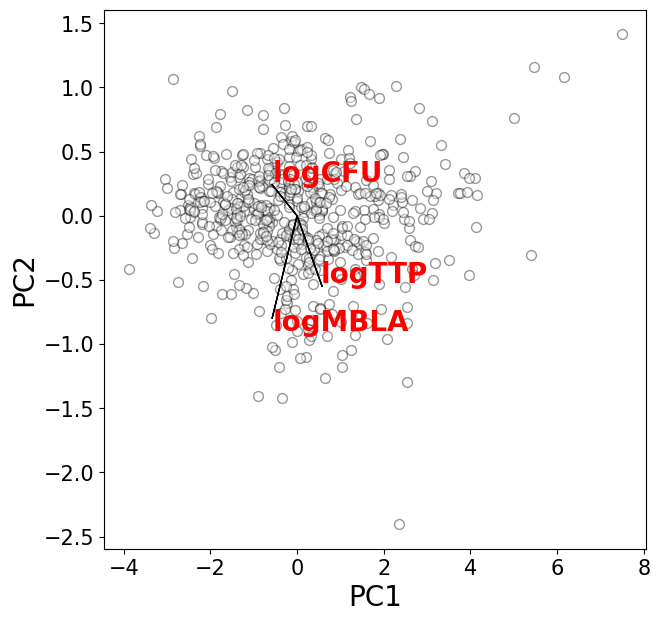

In [32]:
fig , ax = plt.subplots(1, 1, figsize=(7,7))

cmap = sns.color_palette("Greens", n_colors=8)
sns.scatterplot(
    x='pc1', y='pc2', 
#    hue='Day',  
    data=pp_df_full, 
    palette=cmap,
    s=50, 
    facecolor='white',
    edgecolor='black',
    linewidth=1,
    alpha=0.4,
    ax=ax
)

i, j = 0, 1 # which components

ax.set_xlabel('PC%d' % (i+1),fontsize=20)
ax.set_ylabel('PC%d' % (j+1),fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15)

assays = pp_df_full[['logCFU', 'logTTP', 'logMBLA']]#,'Day_scale' 'logTTP',

offsets = {
    'logCFU': (0.01, 0.02),
    'logTTP': (-0.04, 0.03),
    'logMBLA': (0.02, -0.1)
}

for k in range(ppca.C.T.shape[1]):
    x = ppca.C.T[i,k]
    y = ppca.C.T[j,k]
    label = assays.columns[k]
    
    dx, dy = offsets.get(label, (0, 0))  # Default to no offset
    
    ax.arrow(0, 0, x, y)
    ax.text(x + dx, y + dy, label, fontsize=20, fontweight="bold", color='red')

#    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
    
#ax.legend( title="Day")#loc="lower left",
plt.savefig('260112mm_ppcaBiplot_whole_cohort_Nocolor.tiff', bbox_inches='tight',format='tiff',dpi=400)
plt.show()

#### Write out

In [255]:
pp_df_full.to_csv("/Users/mairi.mcclean/Desktop/btz/processed/pca_magic/250620/250620mm_stg2_CTM.csv", index=False) #CTM = CFU,TTP,MBLA

In [245]:
CM_ppca_df_full.to_csv("/Users/mairi.mcclean/Desktop/btz/processed/pca_magic/250620/250620mm_stg2_CT.csv", index=False) #CT = CFU,TTP

In [240]:
MM_ppca_df_full.to_csv("/Users/mairi.mcclean/Desktop/btz/processed/pca_magic/250620/250620mm_stg2_TM.csv", index=False) #TM = TTP, MBLA

In [232]:
CMbla_ppca_df_full.to_csv("/Users/mairi.mcclean/Desktop/btz/processed/pca_magic/250620/250620mm_stg2_CM.csv", index=False) #CM = CFU, MBLA

### PKPD 

> including Phase 1, without Rifampicin patients

In [114]:
X_pca=pkpd.copy()

In [115]:
pp_df = X_pca.drop(columns=['Assigned.Arm', 'stage'])
cols = ['logTTP','logCFU','logMBLA'] #'Day_scale',
subset_df = pp_df[cols]
cs_df = (subset_df - subset_df.mean(0)) / subset_df.std(0) # centre/scale without df grouping
pp_df[cols] = cs_df
pp_df = pp_df.set_index(['Subject.ID','Day'])

In [116]:
pp_df.dropna(axis=0, subset=['logCFU', 'logTTP', 'logMBLA'], how='all', inplace=True) # drop instances of no values
pp_df

logCFU    logTTP   logMBLA
Subject.ID Day                              
11001      0   -1.237235  1.607874 -1.563441
           2   -1.115161  1.734664 -1.777172
           3   -1.923022  2.178268 -2.447330
           4   -0.721159  1.105720 -1.333459
           6   -1.302715  1.862705 -2.524318
...                  ...       ...       ...
22085      11  -1.068380  1.688558 -1.156307
22087      0    0.720907 -0.467284  0.143361
           2    0.391986 -0.254508  0.154541
           3   -0.289190 -0.654103  0.018707
           4   -0.087888  0.143258 -0.175140

[496 rows x 3 columns]

In [117]:
ppca = PPCA()
ppca.fit(pp_df.values, d=2) #(verbose=True) == convergence output # d== n components

In [118]:
variance_explained = ppca.var_exp
components = ppca.data # imputed values
model_params = ppca.C # loadings?
component_mat = ppca.transform() # get components

pp_df['pc1_100'] = component_mat[:,0] # add PC1 to og df
#pp_df['pc2'] = component_mat[:,1] # add PC2 to og df
print(variance_explained)

[0.89962135 0.95660593]


In [119]:
model_params # LOADINGS (features x pcs)

array([[-0.57518027, -0.80781333],
       [ 0.58039534, -0.29198974],
       [-0.57646241,  0.51203478]])

In [120]:
#pp_df=pp_df.reset_index()

##### Different combinations

In [121]:
df = pp_df[['logCFU','logTTP']]
ppca_missing = PPCA()
ppca_missing.fit(df.values, d=2) #(verbose=True) == convergence output # d==n components
variance_explained = ppca_missing.var_exp
print(variance_explained)
components = ppca_missing.data # imputed values
model_params = ppca_missing.C # loadings?
component_mat = ppca_missing.transform() # get components
pp_df['pc1_CT_100'] = component_mat[:,0] # add PC1 to og df

[0.87473734 1.0020202 ]


In [122]:
pp_df_full = pd.merge(pp_df, pkpd[['Subject.ID','Day', 'Assigned.Arm', 'stage']], on=['Subject.ID','Day'], how='left')

#### Plots

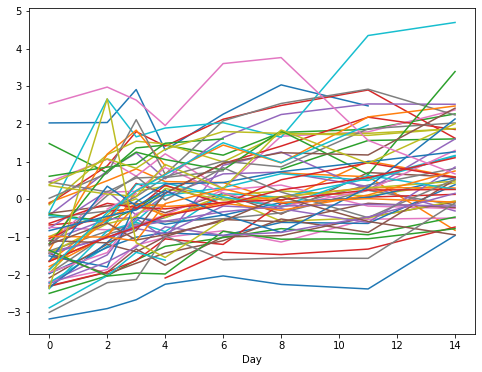

In [129]:
plt.rcParams['figure.figsize'] = [8, 6]
test = CM_ppca_full[["Subject.ID", "Day", "pc1", 'pc2', "Assigned.Arm"]]
df_plot = pd.pivot(test, index="Day", columns="Subject.ID", values="pc1")
pl = df_plot.plot.line()
pl.legend().remove()
plt.show()

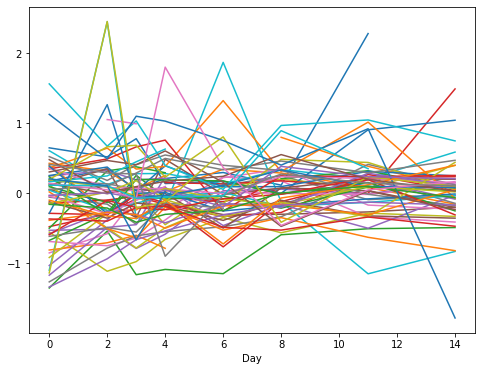

In [130]:
plt.rcParams['figure.figsize'] = [8, 6]
test = CM_ppca_full[["Subject.ID", "Day", "Assigned.Arm", "pc2"]]
df_plot = pd.pivot(test, index="Day", columns="Subject.ID", values="pc2")
#df_plot.index += 1
pl = df_plot.plot.line()
pl.legend().remove()
plt.show()

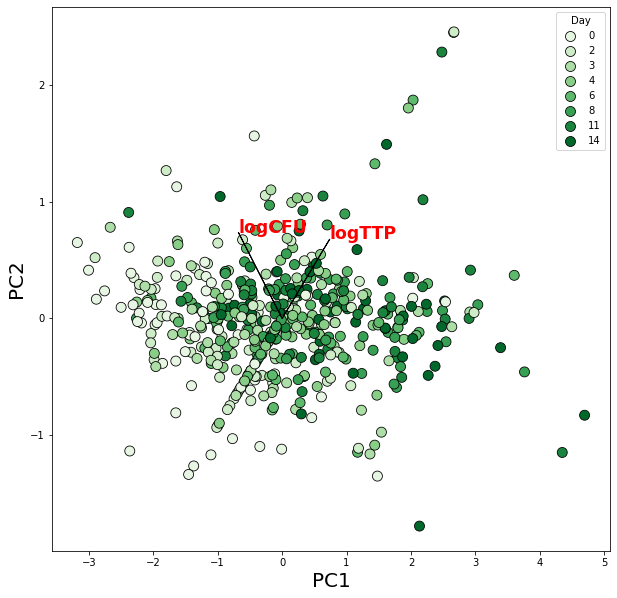

In [131]:
fig , ax = plt.subplots(1, 1, figsize=(10, 10))

cmap = sns.color_palette("Greens", n_colors=8)
sns.scatterplot(
    x='pc1', y='pc2', 
    hue='Day',  
    data=CM_ppca_full, 
    palette=cmap,
    s=100, 
    edgecolor='k',
    alpha=1,
    ax=ax
)

i, j = 0, 1 # which components

ax.set_xlabel('PC%d' % (i+1),fontsize=20)
ax.set_ylabel('PC%d' % (j+1),fontsize=20)


assays = pp_df_full[['logCFU','logTTP','logMBLA']]#,'Day_scale' 'logTTP',

for k in range(ppca.C.T.shape[1]):
    ax.arrow(0, 0, ppca.C.T[i,k], ppca.C.T[j,k])
    ax.text(ppca.C.T[i,k],
            ppca.C.T[j,k],
            assays.columns[k], 
            fontsize="xx-large", 
            fontweight="bold",
            color='red')
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
    
ax.legend( title="Day")#loc="lower left",
plt.show()

In [123]:
loadings_df = pd.DataFrame(ppca.C)
loadings_df

,0,1
0,-0.575507,-0.815145
1,0.580742,-0.350700
2,-0.575787,0.461030


#### Write out

In [283]:
pp_df_full.to_csv("/Users/mairi.mcclean/Desktop/btz/processed/pca_magic/250620/250620mm_stg1_2_CTM_pkpd.csv", index=False) #CTM = CFU,TTP,MBLA; pkpd == no RIF patients

In [277]:
CM_ppca_df_full.to_csv("/Users/mairi.mcclean/Desktop/btz/processed/pca_magic/250620/250620mm_stg1_2_CT_pkpd.csv", index=False) #CT = CFU,TTP; pkpd == no RIF patients

In [271]:
MM_ppca_df_full.to_csv("/Users/mairi.mcclean/Desktop/btz/processed/pca_magic/250620/250620mm_stg1_2_TM_pkpd.csv", index=False) #TM = TTP, MBLA; pkpd == no RIF patients

In [265]:
CMbla_ppca_df_full.to_csv("/Users/mairi.mcclean/Desktop/btz/processed/pca_magic/250620/250620mm_stg1_2_CM_pkpd.csv", index=False) #CM = CFU, MBLA; pkpd == no RIF patients

##### ADD PK parameters to make easier for Simon

In [305]:
### Add AUC values (and HIV) for Simon and write out as complete single df
#  from Simon's data?
pk_df = pd.read_csv('/Users/mairi.mcclean/Desktop/btz/pk/data/AUCs_popPKmodel_BTZ043.csv', index_col=0)

pca_pkids=set(pp_df_full['Subject.ID'].unique())
popPK_ids=set(pk_df.index.unique())
pca_pkids.difference(popPK_ids) # Patients with missing PK - only have markers from day 1; doesn't have P

{22002}

- Merge dfs

In [299]:
### 
pca_df=pd.merge(pp_df_full,CM_ppca_df_full[['Subject.ID', 'Day','pc1']],on=['Subject.ID', 'Day'], how='left')
pca_df=pca_df.drop(columns=['logCFU', 'logTTP', 'logMBLA', 'pc2'])
pca_df=pca_df.rename(columns={'pc1_x':'pc1_all', 'pc1_y':'pc1_CFU_TTP'})

In [300]:
pca_df = pd.merge(pca_df, MM_ppca_df_full[['Subject.ID', 'Day','pc1']],on=['Subject.ID', 'Day'], how='left')
pca_df=pca_df.rename(columns={'pc1':'pc1_TTP_MBLA'})

In [301]:
pca_df = pd.merge(pca_df, CMbla_ppca_df_full[['Subject.ID', 'Day','pc1']],on=['Subject.ID', 'Day'], how='left')
pca_df=pca_df.rename(columns={'pc1':'pc1_CFU_MBLA'})

In [304]:
pca_df = pca_df[['Subject.ID', 'Day', 'Assigned.Arm', 'stage', 'pc1_all', 'pc1_CFU_TTP',
       'pc1_TTP_MBLA', 'pc1_CFU_MBLA']]
pca_df

,Subject.ID,Day,Assigned.Arm,stage,pc1_all,pc1_CFU_TTP,pc1_TTP_MBLA,pc1_CFU_MBLA
0,11001,0,Cohort 1: BTZ 250mg,stage1,2.548787,2.023042,2.244796,1.990113
1,11001,2,Cohort 1: BTZ 250mg,stage1,2.675489,2.033617,2.485715,2.064368
2,11001,3,Cohort 1: BTZ 250mg,stage1,3.785132,2.908146,3.273780,3.105927
3,11001,4,Cohort 1: BTZ 250mg,stage1,1.827154,1.303284,1.726227,1.470446
4,11001,6,Cohort 1: BTZ 250mg,stage1,3.289022,2.255098,3.104415,2.741201
...,...,...,...,...,...,...,...,...
491,22085,11,Arm 1: BTZ 1000mg,stage2,2.263493,1.967941,2.014341,1.576021
492,22087,0,Arm 3: BTZ 250mg,stage2,-0.769339,-0.832994,-0.432639,-0.595099
493,22087,2,Arm 3: BTZ 250mg,stage2,-0.462765,-0.453247,-0.289662,-0.379902
494,22087,3,Arm 3: BTZ 250mg,stage2,-0.224292,-0.285533,-0.477034,0.182674


- Add PK params

In [306]:
pk_df

,AUCM0_popPK,AUCM1_popPK,AUCM2_popPK
Subject.ID,,,
11001,425.397993,4847.30640,5986.55420
11002,391.495053,3511.44720,4274.71088
11003,187.646022,2975.97960,3949.61754
11004,2735.659685,18541.06740,34181.82460
11005,1254.525259,18315.48060,12784.43320
...,...,...,...
22069,793.067376,2809.96056,7963.72500
22073,3037.762102,14475.68820,21906.63640
22077,5488.574970,34072.83900,40431.01920


In [310]:
pca_df = pd.merge(pca_df, pk_df, left_on='Subject.ID', right_on='Subject.ID')
pca_df

,Subject.ID,Day,Assigned.Arm,stage,pc1_all,pc1_CFU_TTP,pc1_TTP_MBLA,pc1_CFU_MBLA,AUCM0_popPK,AUCM1_popPK,AUCM2_popPK
0,11001,0,Cohort 1: BTZ 250mg,stage1,2.548787,2.023042,2.244796,1.990113,425.397993,4847.3064,5986.5542
1,11001,2,Cohort 1: BTZ 250mg,stage1,2.675489,2.033617,2.485715,2.064368,425.397993,4847.3064,5986.5542
2,11001,3,Cohort 1: BTZ 250mg,stage1,3.785132,2.908146,3.273780,3.105927,425.397993,4847.3064,5986.5542
3,11001,4,Cohort 1: BTZ 250mg,stage1,1.827154,1.303284,1.726227,1.470446,425.397993,4847.3064,5986.5542
4,11001,6,Cohort 1: BTZ 250mg,stage1,3.289022,2.255098,3.104415,2.741201,425.397993,4847.3064,5986.5542
...,...,...,...,...,...,...,...,...,...,...,...
490,22085,11,Arm 1: BTZ 1000mg,stage2,2.263493,1.967941,2.014341,1.576021,3542.358985,18952.1010,31762.5858
491,22087,0,Arm 3: BTZ 250mg,stage2,-0.769339,-0.832994,-0.432639,-0.595099,1194.432632,9077.2596,9799.6074
492,22087,2,Arm 3: BTZ 250mg,stage2,-0.462765,-0.453247,-0.289662,-0.379902,1194.432632,9077.2596,9799.6074
493,22087,3,Arm 3: BTZ 250mg,stage2,-0.224292,-0.285533,-0.477034,0.182674,1194.432632,9077.2596,9799.6074


In [ ]:
pca_df.to_csv("/Users/mairi.mcclean/Desktop/btz/processed/pca_magic/250620/250620mm_pca_pk_params.csv", index=False) ## with all pca iterations and popPK params

In [ ]:
### get covariates (WEIGHT, HIV etc) 
covs = pd.read_csv("/Users/mairi.mcclean/Desktop/btz/pk/data/nonmem_data_format_MBLA_w_cov.csv") ## this is in NONMEM format - all techncial repeats are expanded
covs = covs.rename(columns={'ID':'Subject.ID'})

In [327]:
pca_df_covs = pd.merge(pca_df, covs[['Subject.ID', 'HIV', 'Weight', 'Age', 'Sex']], left_on='Subject.ID', right_on='Subject.ID')
pca_df_covs = pca_df_covs.drop_duplicates()
pca_df_covs

,Subject.ID,Day,Assigned.Arm,stage,pc1_all,pc1_CFU_TTP,pc1_TTP_MBLA,pc1_CFU_MBLA,AUCM0_popPK,AUCM1_popPK,AUCM2_popPK,HIV,Weight,Age,Sex
0,11001,0,Cohort 1: BTZ 250mg,stage1,2.548787,2.023042,2.244796,1.990113,425.397993,4847.3064,5986.5542,NEGATIVE,54.1,23,Male
20,11001,2,Cohort 1: BTZ 250mg,stage1,2.675489,2.033617,2.485715,2.064368,425.397993,4847.3064,5986.5542,NEGATIVE,54.1,23,Male
40,11001,3,Cohort 1: BTZ 250mg,stage1,3.785132,2.908146,3.273780,3.105927,425.397993,4847.3064,5986.5542,NEGATIVE,54.1,23,Male
60,11001,4,Cohort 1: BTZ 250mg,stage1,1.827154,1.303284,1.726227,1.470446,425.397993,4847.3064,5986.5542,NEGATIVE,54.1,23,Male
80,11001,6,Cohort 1: BTZ 250mg,stage1,3.289022,2.255098,3.104415,2.741201,425.397993,4847.3064,5986.5542,NEGATIVE,54.1,23,Male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11019,22085,11,Arm 1: BTZ 1000mg,stage2,2.263493,1.967941,2.014341,1.576021,3542.358985,18952.1010,31762.5858,NEGATIVE,59.2,27,Male
11040,22087,0,Arm 3: BTZ 250mg,stage2,-0.769339,-0.832994,-0.432639,-0.595099,1194.432632,9077.2596,9799.6074,NEGATIVE,47.6,26,Male
11052,22087,2,Arm 3: BTZ 250mg,stage2,-0.462765,-0.453247,-0.289662,-0.379902,1194.432632,9077.2596,9799.6074,NEGATIVE,47.6,26,Male
11064,22087,3,Arm 3: BTZ 250mg,stage2,-0.224292,-0.285533,-0.477034,0.182674,1194.432632,9077.2596,9799.6074,NEGATIVE,47.6,26,Male


In [328]:
pca_df_covs.to_csv("/Users/mairi.mcclean/Desktop/btz/processed/pca_magic/250620/250620mm_pca_pk_params_w_covs.csv", index=False) ## with all pca iterations and popPK params

# Sensitivity analysis (% missing data)

> only vary CFU and TTP - no response in MBLA

In [23]:
import itertools

In [123]:
check = pp_df.copy()

In [ ]:
missing_proportions = [0.05,0.1,0.15,0.2,0.25,0.30,0.35,0.40,0.50] ## above 50 already checked to fail in beta testing

# Apply missing values for each proportion - ONLY TTP (MBLA HAS NO SIGNAL; CFU ALREADY CHECKED)
for proportion in missing_proportions:
    new_col = f'logTTP_missing_{int(proportion * 100)}'
    pp_df[new_col] = pp_df['logTTP']
    valid_rows = pp_df[pp_df['logCFU'].notna()].index ## how to change to other columns
    missing_indices = np.random.choice(valid_rows, size=int(proportion * len(valid_rows)), replace=False)
    pp_df.loc[missing_indices, new_col] = np.nan

    ## run PCA on the new column and old standard
    df = pp_df[[new_col,'logCFU']]
    ppca_missing = PPCA()
    ppca_missing.fit(df.values, d=2) #(verbose=True) == convergence output # d==n components
    component_mat = ppca_missing.transform() # get components
    pp_df['pc1_'f'{new_col}'] = component_mat[:,0] # add PC1 to og df

pp_df

In [125]:
missing_props = [0.05,0.1,0.15,0.2,0.25] ## above 25 already pp_dfed to fail

assays = ['logCFU','logTTP']
# Apply missing values for each proportion
for i,j in itertools.combinations(assays, 2):
    for proportion in missing_props:
        new_col1 = f'{i}_missing_{int(proportion * 100)}'
        new_col2 = f'{j}_missing_{int(proportion * 100)}'
                
        pp_df[new_col1] = pp_df[i]
        pp_df[new_col2] = pp_df[i]

        valid_rows = pp_df[pp_df[j].notna()].index
        missing_indices = np.random.choice(valid_rows, size=int(proportion * len(valid_rows)), replace=False)
        pp_df.loc[missing_indices, new_col1] = np.nan

        valid_rows = pp_df[pp_df[i].notna()].index
        missing_indices = np.random.choice(valid_rows, size=int(proportion * len(valid_rows)), replace=False)
        pp_df.loc[missing_indices, new_col2] = np.nan


        ### run pca on the combinations
        df = pp_df[[i,j]]
        ppca_missing = PPCA()
        ppca_missing.fit(df.values, d=2) #(verbose=True) == convergence output # d==n components
        component_mat = ppca_missing.transform() # get components
        pp_df['pc1_CFU_TTP_'f'{proportion}'] = component_mat[:,0] # add PC1 to og df
pp_df

logCFU    logTTP   logMBLA   pc1_100  pc1_CT_100  \
Subject.ID Day                                                       
11001      0   -1.237235  1.607874 -1.563441  2.548787   -2.023042   
           2   -1.115161  1.734664 -1.777172  2.675488   -2.033617   
           3   -1.923022  2.178268 -2.447330  3.785131   -2.908146   
           4   -0.721159  1.105720 -1.333459  1.827154   -1.303284   
           6   -1.302715  1.862705 -2.524318  3.289022   -2.255098   
...                  ...       ...       ...       ...         ...   
22085      11  -1.068380  1.688558 -1.156307  2.263493   -1.967941   
22087      0    0.720907 -0.467284  0.143361 -0.769340    0.832994   
           2    0.391986 -0.254508  0.154541 -0.462765    0.453247   
           3   -0.289190 -0.654103  0.018707 -0.224292    0.285533   
           4   -0.087888  0.143258 -0.175140  0.234905   -0.165093   

                logTTP_missing_5  pc1_logTTP_missing_5  logTTP_missing_10  \
Subject.ID Day                                                              
11001      0           -1.237235             -2.004955                NaN   
           2           -1.115161             -2.007756          -1.115161   
           3           -1.923022             -2.891917          -1.923022   
           4                 NaN             -0.871102                NaN   
           6           -1.302715             -2.230656                NaN   
...                          ...                   ...                ...   
22085      11          -1.068380             -1.290517          -1.068380   
22087      0            0.720907              0.841834           0.720907   
           2            0.391986              0.459214           0.391986   
           3           -0.289190              0.258157          -0.289190   
           4           -0.087888             -0.160472          -0.087888   

                pc1_logTTP_missing_10  logTTP_missing_15  ...  \
Subject.ID Day                                            ...   
11001      0                -2.018269          -1.237235  ...   
           2                -2.020149                NaN  ...   
           3                -2.905494          -1.923022  ...   
           4                -0.852232          -0.721159  ...   
           6                -2.243228          -1.302715  ...   
...                               ...                ...  ...   
22085      11               -1.262561          -1.068380  ...   
22087      0                 0.827562                NaN  ...   
           2                 0.444583           0.391986  ...   
           3                 0.239566          -0.289190  ...   
           4                -0.175292          -0.087888  ...   

                logCFU_missing_5  pc1_CFU_TTP_0.05  logCFU_missing_10  \
Subject.ID Day                                                          
11001      0           -1.237235          2.023042          -1.237235   
           2           -1.115161          2.033617          -1.115161   
           3           -1.923022          2.908146          -1.923022   
           4           -0.721159          1.303284          -0.721159   
           6           -1.302715          2.255098          -1.302715   
...                          ...               ...                ...   
22085      11          -1.068380          1.967941          -1.068380   
22087      0            0.720907         -0.832994           0.720907   
           2            0.391986         -0.453247           0.391986   
           3           -0.289190         -0.285533                NaN   
           4           -0.087888          0.165093          -0.087888   

                pc1_CFU_TTP_0.1  logCFU_missing_15  pc1_CFU_TTP_0.15  \
Subject.ID Day                                                         
11001      0           2.015732          -1.237235          2.015713   
           2           2.020285          -1.115161          2.020251   
           3         

In [127]:
pp_df=pp_df.reset_index()

In [128]:
ppca_full = pd.merge(pp_df, df_full[['Subject.ID','Day','Assigned.Arm','stage']], on=['Subject.ID', 'Day'], how='left')

- ADD NONMEM COVS FOR SIMON

In [129]:
### Add AUC values (and HIV) for Simon and write out as complete single df
#  from Simon's data?
pk_df = pd.read_csv('/Users/mairi.mcclean/Desktop/btz/pk/data/AUCs_popPKmodel_BTZ043.csv', index_col=0)

pca_pkids=set(pp_df_full['Subject.ID'].unique())
popPK_ids=set(pk_df.index.unique())
pca_pkids.difference(popPK_ids) # Patients with missing PK - only have markers from day 1; doesn't have P

{np.int64(22002)}

- Add PK params

In [130]:
pca_df = pd.merge(ppca_full, pk_df, left_on='Subject.ID', right_on='Subject.ID')
pca_df

,Subject.ID,Day,logCFU,logTTP,logMBLA,pc1_100,pc1_CT_100,logTTP_missing_5,pc1_logTTP_missing_5,logTTP_missing_10,...,pc1_CFU_TTP_0.15,logCFU_missing_20,pc1_CFU_TTP_0.2,logCFU_missing_25,pc1_CFU_TTP_0.25,Assigned.Arm,stage,AUCM0_popPK,AUCM1_popPK,AUCM2_popPK
0,11001,0,-1.237235,1.607874,-1.563441,2.548787,-2.023042,-1.237235,-2.004955,NaN,...,2.015713,-1.237235,-2.023042,-1.237235,2.023042,Cohort 1: BTZ 250mg,Stage 1,425.397993,4847.3064,5986.5542
1,11001,2,-1.115161,1.734664,-1.777172,2.675488,-2.033617,-1.115161,-2.007756,-1.115161,...,2.020251,-1.115161,-2.033617,-1.115161,2.033617,Cohort 1: BTZ 250mg,Stage 1,425.397993,4847.3064,5986.5542
2,11001,3,-1.923022,2.178268,-2.447330,3.785131,-2.908146,-1.923022,-2.891917,-1.923022,...,2.904350,-1.923022,-2.908146,-1.923022,2.908146,Cohort 1: BTZ 250mg,Stage 1,425.397993,4847.3064,5986.5542
3,11001,4,-0.721159,1.105720,-1.333459,1.827154,-1.303284,NaN,-0.871102,NaN,...,1.295021,-0.721159,-1.303284,-0.721159,1.303284,Cohort 1: BTZ 250mg,Stage 1,425.397993,4847.3064,5986.5542
4,11001,6,-1.302715,1.862705,-2.524318,3.289022,-2.255098,-1.302715,-2.230656,NaN,...,2.243361,-1.302715,-2.255098,-1.302715,2.255098,Cohort 1: BTZ 250mg,Stage 1,425.397993,4847.3064,5986.5542
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
490,22085,11,-1.068380,1.688558,-1.156307,2.263493,-1.967941,-1.068380,-1.290517,-1.068380,...,1.954505,NaN,-1.967941,-1.068380,1.967941,Arm 1: BTZ 1000mg,Stage 2,3542.358985,18952.1010,31762.5858
491,22087,0,0.720907,-0.467284,0.143361,-0.769340,0.832994,0.720907,0.841834,0.720907,...,-0.839843,0.720907,0.832994,0.720907,-0.832994,Arm 3: BTZ 250mg,Stage 2,1194.432632,9077.2596,9799.6074
492,22087,2,0.391986,-0.254508,0.154541,-0.462765,0.453247,0.391986,0.459214,0.391986,...,-0.456961,NaN,0.453247,NaN,-0.453247,Arm 3: BTZ 250mg,Stage 2,1194.432632,9077.2596,9799.6074
493,22087,3,-0.289190,-0.654103,0.018707,-0.224292,0.285533,-0.289190,0.258157,-0.289190,...,-0.262858,-0.289190,0.285533,-0.289190,-0.285533,Arm 3: BTZ 250mg,Stage 2,1194.432632,9077.2596,9799.6074


In [131]:
### get covariates (WEIGHT, HIV etc) 
covs = pd.read_csv("/Users/mairi.mcclean/Desktop/btz/pk/data/nonmem_data_format_MBLA_w_cov.csv") ## this is in NONMEM format - all techncial repeats are expanded
covs = covs.rename(columns={'ID':'Subject.ID'})

In [132]:
pca_df_covs = pd.merge(pca_df, covs[['Subject.ID', 'HIV', 'Weight', 'Age', 'Sex']], left_on='Subject.ID', right_on='Subject.ID')
pca_df_covs = pca_df_covs.drop_duplicates()
pca_df_covs

,Subject.ID,Day,logCFU,logTTP,logMBLA,pc1_100,pc1_CT_100,logTTP_missing_5,pc1_logTTP_missing_5,logTTP_missing_10,...,pc1_CFU_TTP_0.25,Assigned.Arm,stage,AUCM0_popPK,AUCM1_popPK,AUCM2_popPK,HIV,Weight,Age,Sex
0,11001,0,-1.237235,1.607874,-1.563441,2.548787,-2.023042,-1.237235,-2.004955,NaN,...,2.023042,Cohort 1: BTZ 250mg,Stage 1,425.397993,4847.3064,5986.5542,NEGATIVE,54.1,23,Male
20,11001,2,-1.115161,1.734664,-1.777172,2.675488,-2.033617,-1.115161,-2.007756,-1.115161,...,2.033617,Cohort 1: BTZ 250mg,Stage 1,425.397993,4847.3064,5986.5542,NEGATIVE,54.1,23,Male
40,11001,3,-1.923022,2.178268,-2.447330,3.785131,-2.908146,-1.923022,-2.891917,-1.923022,...,2.908146,Cohort 1: BTZ 250mg,Stage 1,425.397993,4847.3064,5986.5542,NEGATIVE,54.1,23,Male
60,11001,4,-0.721159,1.105720,-1.333459,1.827154,-1.303284,NaN,-0.871102,NaN,...,1.303284,Cohort 1: BTZ 250mg,Stage 1,425.397993,4847.3064,5986.5542,NEGATIVE,54.1,23,Male
80,11001,6,-1.302715,1.862705,-2.524318,3.289022,-2.255098,-1.302715,-2.230656,NaN,...,2.255098,Cohort 1: BTZ 250mg,Stage 1,425.397993,4847.3064,5986.5542,NEGATIVE,54.1,23,Male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11019,22085,11,-1.068380,1.688558,-1.156307,2.263493,-1.967941,-1.068380,-1.290517,-1.068380,...,1.967941,Arm 1: BTZ 1000mg,Stage 2,3542.358985,18952.1010,31762.5858,NEGATIVE,59.2,27,Male
11040,22087,0,0.720907,-0.467284,0.143361,-0.769340,0.832994,0.720907,0.841834,0.720907,...,-0.832994,Arm 3: BTZ 250mg,Stage 2,1194.432632,9077.2596,9799.6074,NEGATIVE,47.6,26,Male
11052,22087,2,0.391986,-0.254508,0.154541,-0.462765,0.453247,0.391986,0.459214,0.391986,...,-0.453247,Arm 3: BTZ 250mg,Stage 2,1194.432632,9077.2596,9799.6074,NEGATIVE,47.6,26,Male
11064,22087,3,-0.289190,-0.654103,0.018707,-0.224292,0.285533,-0.289190,0.258157,-0.289190,...,-0.285533,Arm 3: BTZ 250mg,Stage 2,1194.432632,9077.2596,9799.6074,NEGATIVE,47.6,26,Male


In [133]:
### drop unwanted columns
pca_df_covs.columns

Index(['Subject.ID', 'Day', 'logCFU', 'logTTP', 'logMBLA', 'pc1_100',
       'pc1_CT_100', 'logTTP_missing_5', 'pc1_logTTP_missing_5',
       'logTTP_missing_10', 'pc1_logTTP_missing_10', 'logTTP_missing_15',
       'pc1_logTTP_missing_15', 'logTTP_missing_20', 'pc1_logTTP_missing_20',
       'logTTP_missing_25', 'pc1_logTTP_missing_25', 'logTTP_missing_30',
       'pc1_logTTP_missing_30', 'logTTP_missing_35', 'pc1_logTTP_missing_35',
       'logTTP_missing_40', 'pc1_logTTP_missing_40', 'logTTP_missing_50',
       'logCFU_missing_5', 'pc1_CFU_TTP_0.05', 'logCFU_missing_10',
       'pc1_CFU_TTP_0.1', 'logCFU_missing_15', 'pc1_CFU_TTP_0.15',
       'logCFU_missing_20', 'pc1_CFU_TTP_0.2', 'logCFU_missing_25',
       'pc1_CFU_TTP_0.25', 'Assigned.Arm', 'stage', 'AUCM0_popPK',
       'AUCM1_popPK', 'AUCM2_popPK', 'HIV', 'Weight', 'Age', 'Sex'],
      dtype='object')

In [ ]:
pca_df_covs.drop(columns=['logMBLA', 'pc1_100','logTTP_missing_10','logTTP_missing_20','logTTP_missing_30','logTTP_missing_40',
                          'logTTP_missing_50','logTTP_missing_5','logTTP_missing_5', 'logTTP_missing_10','logTTP_missing_15', 
                          'logTTP_missing_15', 'logTTP_missing_20', 'logTTP_missing_25', 'logTTP_missing_35',
                          'logCFU_missing_5','logCFU_missing_10','logCFU_missing_15','logCFU_missing_20',
                          'logCFU_missing_25'], inplace=True)

In [141]:
pca_df_covs.columns

Index(['Subject.ID', 'Day', 'logCFU', 'logTTP', 'pc1_CT_100',
       'pc1_logTTP_missing_5', 'pc1_logTTP_missing_10',
       'pc1_logTTP_missing_15', 'pc1_logTTP_missing_20',
       'pc1_logTTP_missing_25', 'pc1_logTTP_missing_30',
       'pc1_logTTP_missing_35', 'pc1_logTTP_missing_40', 'pc1_CFU_TTP_0.05',
       'pc1_CFU_TTP_0.1', 'pc1_CFU_TTP_0.15', 'pc1_CFU_TTP_0.2',
       'pc1_CFU_TTP_0.25', 'Assigned.Arm', 'stage', 'AUCM0_popPK',
       'AUCM1_popPK', 'AUCM2_popPK', 'HIV', 'Weight', 'Age', 'Sex'],
      dtype='object')

In [ ]:
#pca_df_covs.to_csv("/Users/mairi.mcclean/Desktop/btz/manuscript_posters/CPT_PSP_submission/submitted/revisions/extra_analysis/processed_data/sensitivity_analysis/260528mm_ppca_sensanalysis_wCovs.csv", index=False) ## with all pca iterations and popPK params

In [ ]:
pca_df_covs.drop(columns=['pc1_CT_100',
       'pc1_logTTP_missing_25', 'pc1_logTTP_missing_30',
       'pc1_logTTP_missing_35', 'pc1_logTTP_missing_40','pc1_CFU_TTP_0.2','pc1_CFU_TTP_0.25', ], inplace=True)

In [ ]:

pca_df_covs.to_csv("/Users/mairi.mcclean/Desktop/btz/manuscript_posters/CPT_PSP_submission/submitted/revisions/extra_analysis/processed_data/sensitivity_analysis/260605mm_ppca_sensanalysis_wCovs.csv", index=False) ## with less iterations to make faster for Simon